In [1]:
# Импорт библиотек для работы с данными и визуализации
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Импорт модулей для кластеризации и предобработки
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Импорт метрик для оценки качества кластеризации
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
def make_data(n, seed):
    """
    Функция для создания синтетического набора данных с тремя группами.
    
    Параметры:
    n - число объектов в каждой группе
    seed - зерно для воспроизводимости случайных значений
    
    Возвращает:
    DataFrame с признаками 'x' и 'y'
    """
    np.random.seed(seed)
    
    # Координаты центров трех групп
    shift_matrix = np.array([[3, 3], [6, 9], [9, 3]])
    
    # Генерация точек с нормальным распределением вокруг центров
    data = np.random.randn(3, 2, n) + shift_matrix.reshape((3, 2, 1))
    
    data = np.swapaxes(data, 1, 2)
    data = data.reshape((-1, 2))
    
    # Масштабирование признаков для создания вытянутой формы
    data *= np.array([[20, 0.5]])
    
    # Создание DataFrame
    df = pd.DataFrame({'x': data[:, 0], 'y': data[:, 1]}, columns=['x', 'y'])
    
    # Перемешивание строк
    df = df.sample(frac=1.0, random_state=seed)
    
    return df

# Генерация данных: 100 объектов в каждой группе, всего 300 объектов
df = make_data(n=100, seed=42)
print(f"Размер набора данных: {df.shape}")
print(f"Первые 5 строк:\n{df.head()}")


Размер набора данных: (300, 2)
Первые 5 строк:
              x         y
203  180.939612  1.781485
266  192.283334  0.480938
152  162.443124  4.928830
9     70.851201  1.462777
233  194.350845  0.894492


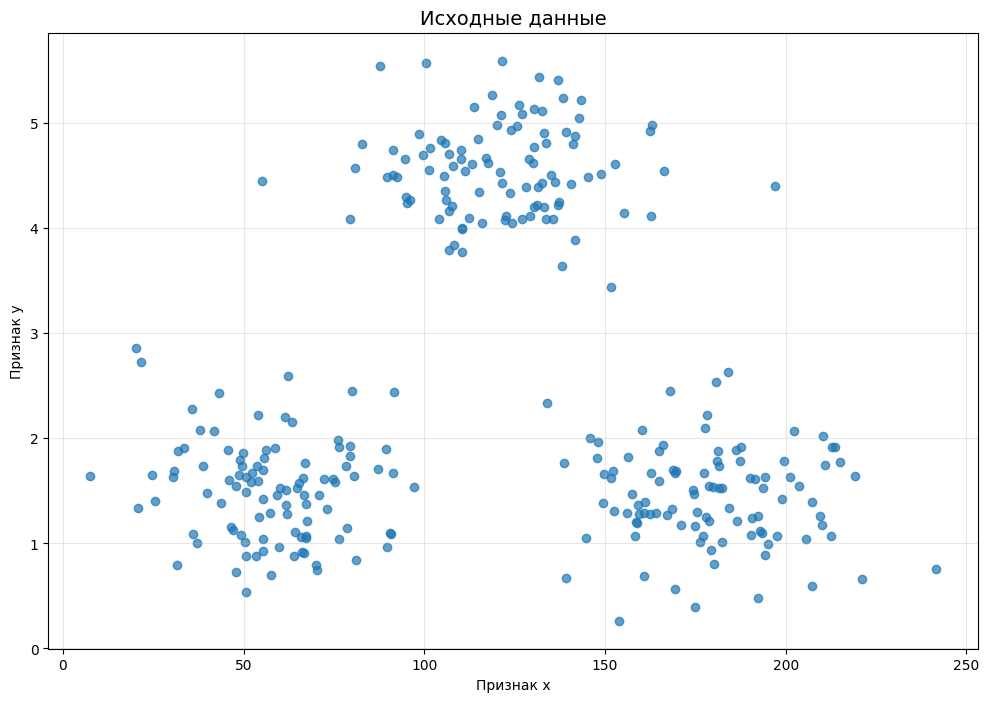

In [3]:
# Визуализация исходных данных
plt.figure(figsize=(12, 8))
plt.scatter(df['x'], df['y'], alpha=0.7)
plt.title('Исходные данные', fontsize=14)
plt.xlabel('Признак x')
plt.ylabel('Признак y')
plt.grid(True, alpha=0.3)
plt.show()


Статистика до стандартизации:
Среднее x: 119.367, Стандартное отклонение x: 53.509
Среднее y: 2.502, Стандартное отклонение y: 1.524

Статистика после стандартизации:
Среднее x_scaled: -0.000, Стандартное отклонение x_scaled: 1.002
Среднее y_scaled: 0.000, Стандартное отклонение y_scaled: 1.002


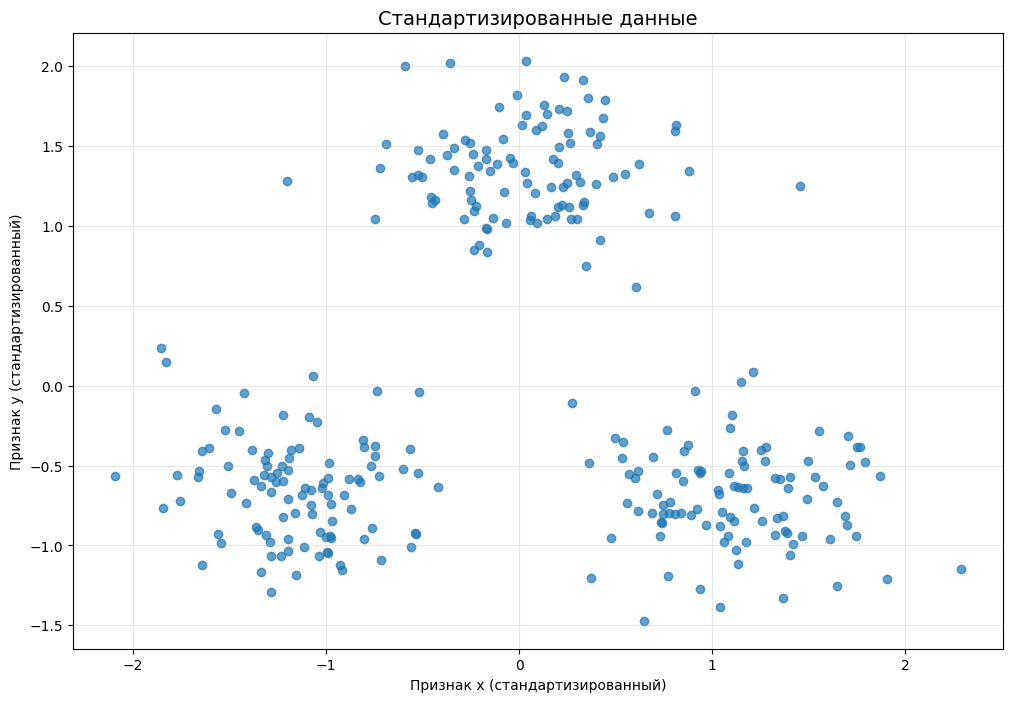

In [4]:
# Стандартизация данных
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=['x_scaled', 'y_scaled'])
print("Статистика до стандартизации:")
print(f"Среднее x: {df['x'].mean():.3f}, Стандартное отклонение x: {df['x'].std():.3f}")
print(f"Среднее y: {df['y'].mean():.3f}, Стандартное отклонение y: {df['y'].std():.3f}")
print("\nСтатистика после стандартизации:")
print(f"Среднее x_scaled: {df_scaled['x_scaled'].mean():.3f}, Стандартное отклонение x_scaled: {df_scaled['x_scaled'].std():.3f}")
print(f"Среднее y_scaled: {df_scaled['y_scaled'].mean():.3f}, Стандартное отклонение y_scaled: {df_scaled['y_scaled'].std():.3f}")

# Визуализация стандартизированных данных
plt.figure(figsize=(12, 8))
plt.scatter(df_scaled['x_scaled'], df_scaled['y_scaled'], alpha=0.7)
plt.title('Стандартизированные данные', fontsize=14)
plt.xlabel('Признак x (стандартизированный)')
plt.ylabel('Признак y (стандартизированный)')
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
# Обучение модели K-means с 3 кластерами
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(df_scaled)

# Добавление меток кластеров в DataFrame
df_scaled['cluster_3'] = clusters_3

# Получение центров кластеров
centers_3 = kmeans_3.cluster_centers_

print(f"Количество итераций: {kmeans_3.n_iter_}")
print(f"Инерция (сумма квадратов расстояний): {kmeans_3.inertia_:.2f}")


Количество итераций: 3
Инерция (сумма квадратов расстояний): 70.67


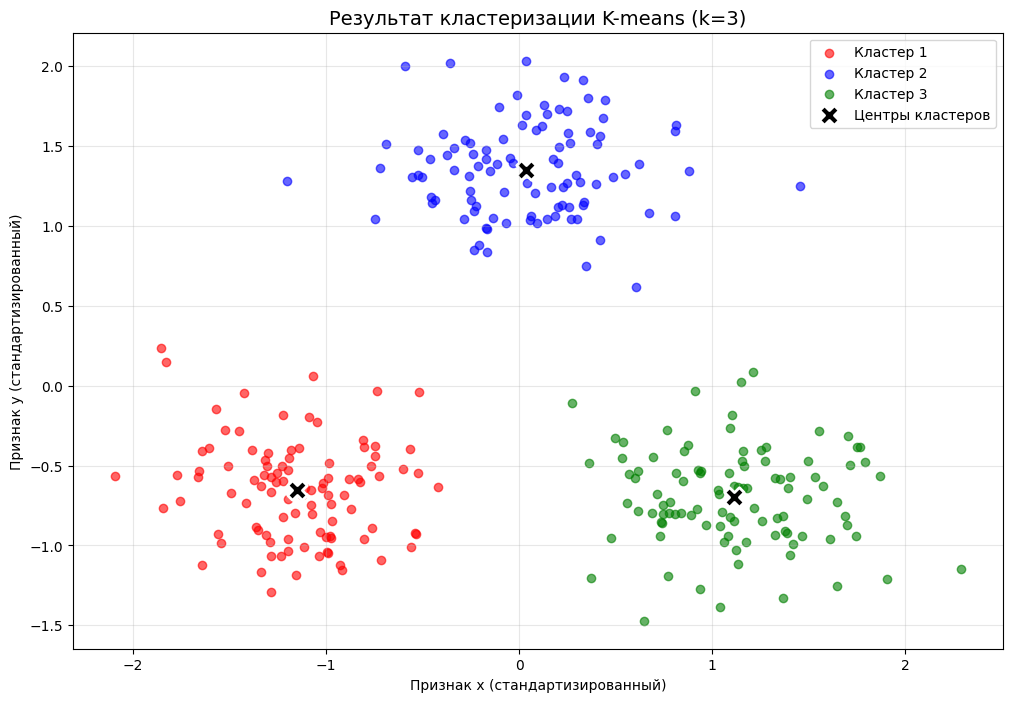

In [6]:
# Визуализация кластеров на обучающих данных
plt.figure(figsize=(12, 8))

# Цвета для кластеров
colors = ['red', 'blue', 'green']
for i in range(3):
    cluster_data = df_scaled[df_scaled['cluster_3'] == i]
    plt.scatter(cluster_data['x_scaled'], cluster_data['y_scaled'], 
                color=colors[i], label=f'Кластер {i+1}', alpha=0.6)

# Отображение центров кластеров
plt.scatter(centers_3[:, 0], centers_3[:, 1], 
            color='black', marker='X', s=200, 
            label='Центры кластеров', edgecolors='white', linewidth=2)

plt.title('Результат кластеризации K-means (k=3)', fontsize=14)
plt.xlabel('Признак x (стандартизированный)')
plt.ylabel('Признак y (стандартизированный)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Размер тестового набора: (90, 3)


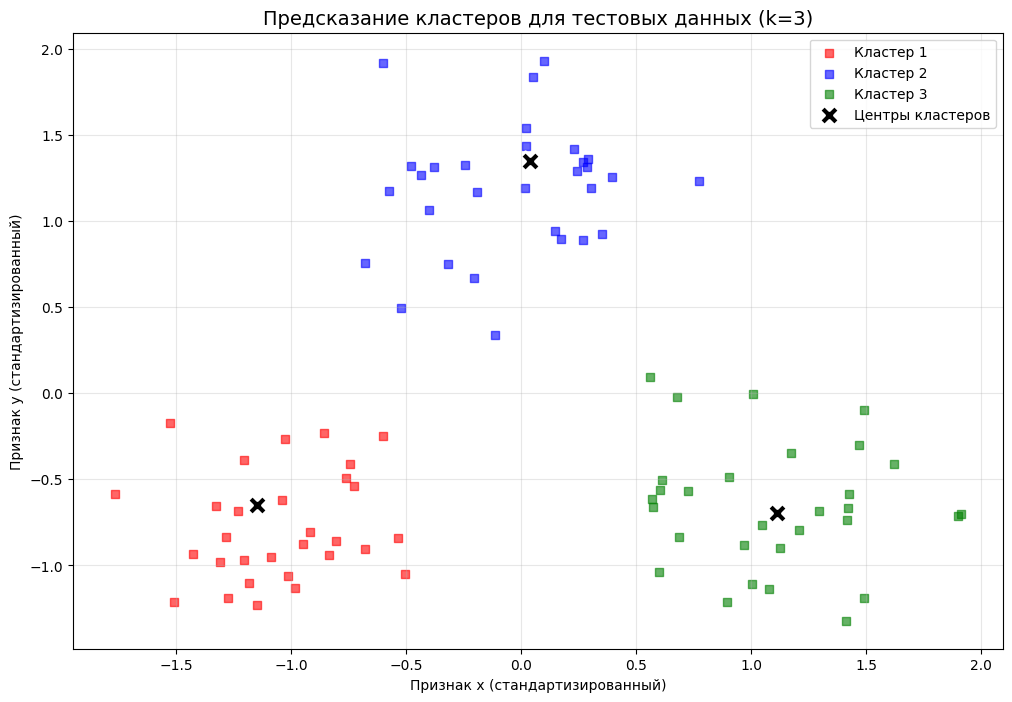

In [7]:
# Создание тестовых данных
test_data = make_data(n=30, seed=100)  # 30 объектов в каждой группе, всего 90 объектов

# Стандартизация тестовых данных (используем тот же scaler)
test_scaled = scaler.transform(test_data)
test_scaled = pd.DataFrame(test_scaled, columns=['x_scaled', 'y_scaled'])

# Предсказание кластеров для тестовых данных
test_clusters = kmeans_3.predict(test_scaled)
test_scaled['cluster'] = test_clusters
print(f"Размер тестового набора: {test_scaled.shape}")

# Визуализация тестовых данных с предсказанными кластерами
plt.figure(figsize=(12, 8))
for i in range(3):
    cluster_data = test_scaled[test_scaled['cluster'] == i]
    plt.scatter(cluster_data['x_scaled'], cluster_data['y_scaled'], 
                color=colors[i], label=f'Кластер {i+1}', alpha=0.6, marker='s')

# Отображение центров кластеров (обученных на train)
plt.scatter(centers_3[:, 0], centers_3[:, 1], 
            color='black', marker='X', s=200, 
            label='Центры кластеров', edgecolors='white', linewidth=2)
plt.title('Предсказание кластеров для тестовых данных (k=3)', fontsize=14)
plt.xlabel('Признак x (стандартизированный)')
plt.ylabel('Признак y (стандартизированный)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# Коэффициент силуэта (не требует истинных меток)
silhouette_3 = silhouette_score(df_scaled[['x_scaled', 'y_scaled']], clusters_3)
print(f"Коэффициент силуэта для k=3: {silhouette_3:.4f}")

# Коэффициент силуэта для тестовых данных
silhouette_test = silhouette_score(test_scaled[['x_scaled', 'y_scaled']], test_clusters)
print(f"Коэффициент силуэта для тестовых данных: {silhouette_test:.4f}")

# Создадим истинные метки для сравнения (известны из структуры данных)
true_labels = np.array([0]*100 + [1]*100 + [2]*100)  # 100 точек в каждой группе
np.random.seed(42)
# Перемешиваем в том же порядке, что и df
indices = np.random.permutation(300)
true_labels_shuffled = true_labels[indices]

# Внешние метрики (требуют истинных меток)
print("\n--- Внешние метрики качества (k=3) ---")
print(f"AMI (Adjusted Mutual Information): {adjusted_mutual_info_score(true_labels_shuffled, clusters_3):.4f}")
print(f"ARI (Adjusted Rand Index): {adjusted_rand_score(true_labels_shuffled, clusters_3):.4f}")
print(f"FMI (Fowlkes-Mallows Index): {fowlkes_mallows_score(true_labels_shuffled, clusters_3):.4f}")
print(f"Homogeneity (Однородность): {homogeneity_score(true_labels_shuffled, clusters_3):.4f}")
print(f"Completeness (Полнота): {completeness_score(true_labels_shuffled, clusters_3):.4f}")
print(f"V-measure: {v_measure_score(true_labels_shuffled, clusters_3):.4f}")


Коэффициент силуэта для k=3: 0.7186
Коэффициент силуэта для тестовых данных: 0.6819

--- Внешние метрики качества (k=3) ---
AMI (Adjusted Mutual Information): 1.0000
ARI (Adjusted Rand Index): 1.0000
FMI (Fowlkes-Mallows Index): 1.0000
Homogeneity (Однородность): 1.0000
Completeness (Полнота): 1.0000
V-measure: 1.0000


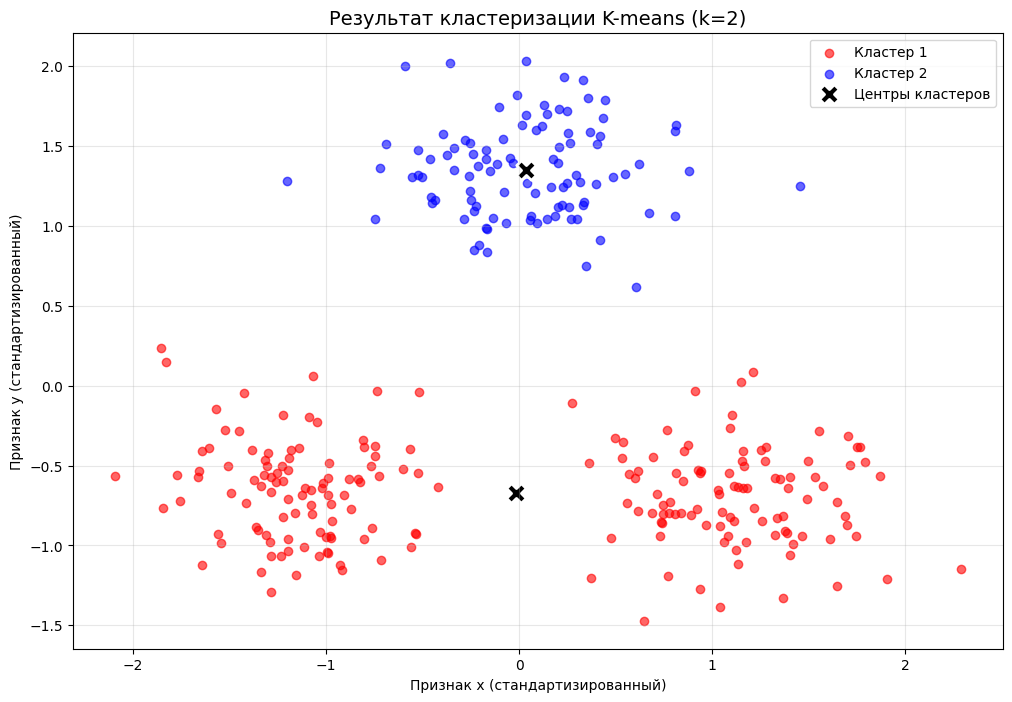

Коэффициент силуэта для k=2: 0.4997


In [10]:
# Кластеризация с 2 кластерами
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_2 = kmeans_2.fit_predict(df_scaled[['x_scaled', 'y_scaled']])
centers_2 = kmeans_2.cluster_centers_

# Визуализация
plt.figure(figsize=(12, 8))
for i in range(2):
    cluster_data = df_scaled['x_scaled']  # временный признак для визуализации
    # Создаем временную колонку для кластеров
    df_scaled_temp = df_scaled.copy()
    df_scaled_temp['cluster_2'] = clusters_2
    cluster_data = df_scaled_temp[df_scaled_temp['cluster_2'] == i]
    plt.scatter(cluster_data['x_scaled'], cluster_data['y_scaled'], 
                color=['red', 'blue'][i], label=f'Кластер {i+1}', alpha=0.6)
plt.scatter(centers_2[:, 0], centers_2[:, 1], 
            color='black', marker='X', s=200, 
            label='Центры кластеров', edgecolors='white', linewidth=2)
plt.title('Результат кластеризации K-means (k=2)', fontsize=14)
plt.xlabel('Признак x (стандартизированный)')
plt.ylabel('Признак y (стандартизированный)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества
silhouette_2 = silhouette_score(df_scaled[['x_scaled', 'y_scaled']], clusters_2)
print(f"Коэффициент силуэта для k=2: {silhouette_2:.4f}")

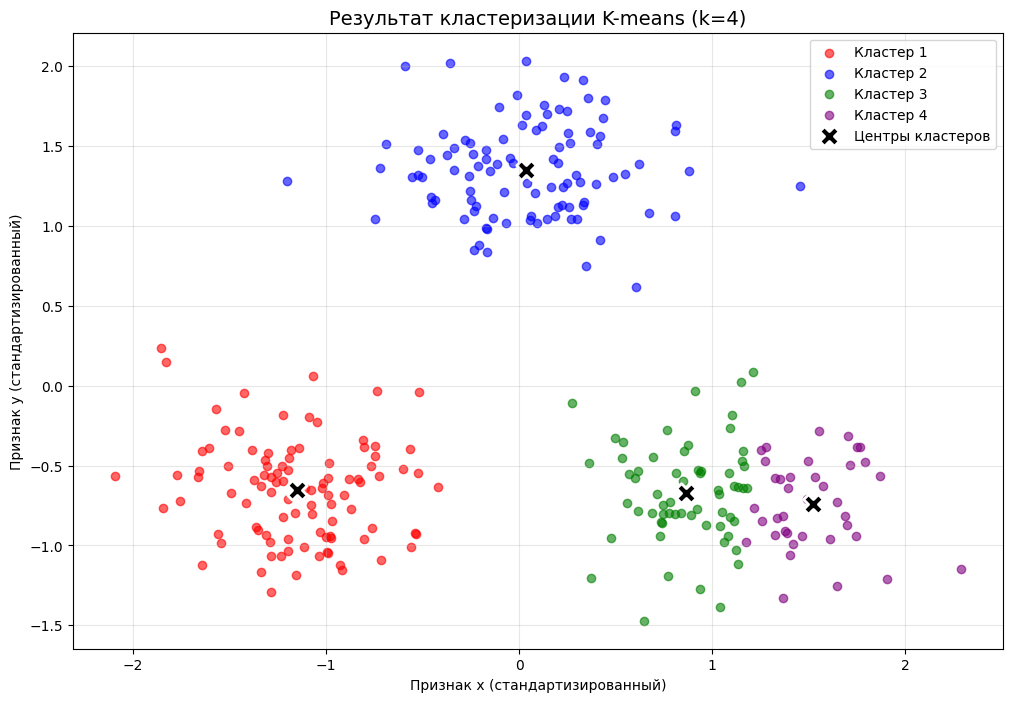

Коэффициент силуэта для k=4: 0.5938


In [11]:
# Кластеризация с 4 кластерами
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_4 = kmeans_4.fit_predict(df_scaled[['x_scaled', 'y_scaled']])
centers_4 = kmeans_4.cluster_centers_

# Визуализация
plt.figure(figsize=(12, 8))
colors_4 = ['red', 'blue', 'green', 'purple']
df_scaled_temp = df_scaled.copy()
df_scaled_temp['cluster_4'] = clusters_4
for i in range(4):
    cluster_data = df_scaled_temp[df_scaled_temp['cluster_4'] == i]
    plt.scatter(cluster_data['x_scaled'], cluster_data['y_scaled'], 
                color=colors_4[i], label=f'Кластер {i+1}', alpha=0.6)
plt.scatter(centers_4[:, 0], centers_4[:, 1], 
            color='black', marker='X', s=200, 
            label='Центры кластеров', edgecolors='white', linewidth=2)
plt.title('Результат кластеризации K-means (k=4)', fontsize=14)
plt.xlabel('Признак x (стандартизированный)')
plt.ylabel('Признак y (стандартизированный)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оценка качества
silhouette_4 = silhouette_score(df_scaled[['x_scaled', 'y_scaled']], clusters_4)
print(f"Коэффициент силуэта для k=4: {silhouette_4:.4f}")


In [12]:
# Сравнение результатов для разных k
print("\n=== СРАВНЕНИЕ КАЧЕСТВА КЛАСТЕРИЗАЦИИ ===")
print("-" * 50)
print(f"{'Метрика':<30} {'k=2':<10} {'k=3':<10} {'k=4':<10}")
print("-" * 50)
print(f"{'Коэффициент силуэта':<30} {silhouette_2:<10.4f} {silhouette_3:<10.4f} {silhouette_4:<10.4f}")
print(f"{'Количество итераций':<30} {kmeans_2.n_iter_:<10} {kmeans_3.n_iter_:<10} {kmeans_4.n_iter_:<10}")
print(f"{'Инерция':<30} {kmeans_2.inertia_:<10.2f} {kmeans_3.inertia_:<10.2f} {kmeans_4.inertia_:<10.2f}")
print("-" * 50)



=== СРАВНЕНИЕ КАЧЕСТВА КЛАСТЕРИЗАЦИИ ===
--------------------------------------------------
Метрика                        k=2        k=3        k=4       
--------------------------------------------------
Коэффициент силуэта            0.4997     0.7186     0.5938    
Количество итераций            4          3          7         
Инерция                        327.11     70.67      60.32     
--------------------------------------------------


In [13]:
# Анализ необходимости деления данных для кластеризации
print("\n=== АНАЛИЗ НЕОБХОДИМОСТИ ДЕЛЕНИЯ ДАННЫХ ===")
print("""
Вопрос: Необходимо ли в кластеризации выполнять деление данных на train и test?
Ответ: В задачах кластеризации (обучение без учителя) деление на train/test 
не является обязательным, в отличие от задач классификации/регрессии.
Причины:
1. Кластеризация не предсказывает целевую переменную, а ищет структуру в данных
2. Нет "правильного ответа" для проверки качества на отложенной выборке
3. Модель кластеризации описывает структуру данных, а не зависимость

Однако деление может быть полезно в следующих случаях:
1. Проверка устойчивости кластеров - если кластеры на train и test похожи
2. Оценка обобщающей способности - как модель работает на новых данных
3. Предотвращение переобучения - слишком сложная структура не будет воспроизводиться
В данной работе мы выполнили деление для демонстрации возможности 
предсказания кластеров для новых данных.
""")



=== АНАЛИЗ НЕОБХОДИМОСТИ ДЕЛЕНИЯ ДАННЫХ ===

Вопрос: Необходимо ли в кластеризации выполнять деление данных на train и test?
Ответ: В задачах кластеризации (обучение без учителя) деление на train/test 
не является обязательным, в отличие от задач классификации/регрессии.
Причины:
1. Кластеризация не предсказывает целевую переменную, а ищет структуру в данных
2. Нет "правильного ответа" для проверки качества на отложенной выборке
3. Модель кластеризации описывает структуру данных, а не зависимость

Однако деление может быть полезно в следующих случаях:
1. Проверка устойчивости кластеров - если кластеры на train и test похожи
2. Оценка обобщающей способности - как модель работает на новых данных
3. Предотвращение переобучения - слишком сложная структура не будет воспроизводиться
В данной работе мы выполнили деление для демонстрации возможности 
предсказания кластеров для новых данных.



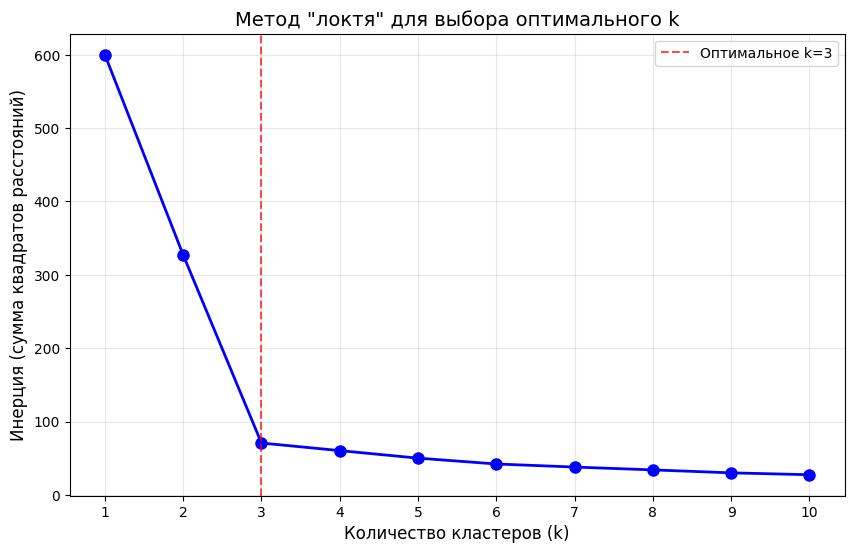


=== АНАЛИЗ МЕТОДА 'ЛОКТЯ' ===
На графике видно резкое изменение угла наклона при k=3.
После k=3 снижение инерции замедляется, что указывает на то,
что добавление новых кластеров не дает значительного улучшения.
Таким образом, оптимальное количество кластеров для данных - 3.


In [14]:
# Метод локтя для определения оптимального числа кластеров
inertia_values = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled[['x_scaled', 'y_scaled']])
    inertia_values.append(kmeans.inertia_)

# Построение графика "локтя"
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
plt.title('Метод "локтя" для выбора оптимального k', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Отметка точки "локтя"
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Оптимальное k=3')
plt.legend()
plt.show()
print("\n=== АНАЛИЗ МЕТОДА 'ЛОКТЯ' ===")
print("На графике видно резкое изменение угла наклона при k=3.")
print("После k=3 снижение инерции замедляется, что указывает на то,")
print("что добавление новых кластеров не дает значительного улучшения.")
print("Таким образом, оптимальное количество кластеров для данных - 3.")



=== СРЕДНИЕ ЗНАЧЕНИЯ ПРИЗНАКОВ ПО КЛАСТЕРАМ ===
                  x         y
cluster                      
0         57.923070  1.511152
1        121.297925  4.553420
2        178.879911  1.442347


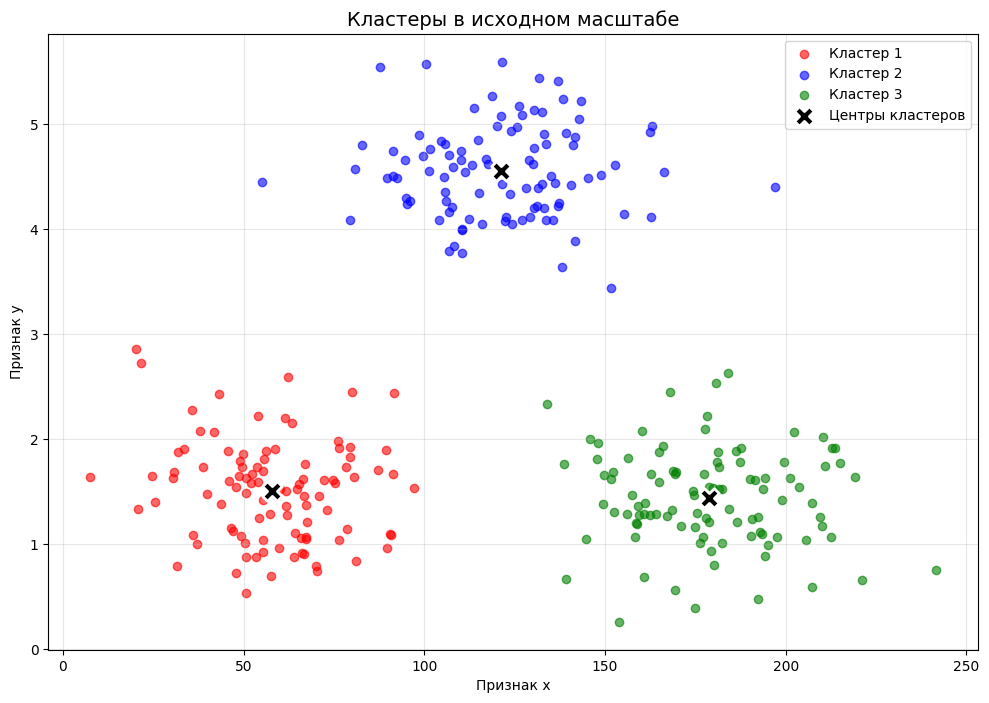

In [15]:
# Анализ средних значений по кластерам (для исходных данных)
df_with_clusters = df.copy()
df_with_clusters['cluster'] = clusters_3
cluster_means = df_with_clusters.groupby('cluster').mean()
print("\n=== СРЕДНИЕ ЗНАЧЕНИЯ ПРИЗНАКОВ ПО КЛАСТЕРАМ ===")
print(cluster_means)

# Визуализация кластеров в исходном масштабе
plt.figure(figsize=(12, 8))
for i in range(3):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    plt.scatter(cluster_data['x'], cluster_data['y'], 
                color=colors[i], label=f'Кластер {i+1}', alpha=0.6)

# Восстановление центров в исходном масштабе
centers_original = scaler.inverse_transform(centers_3)
plt.scatter(centers_original[:, 0], centers_original[:, 1], 
            color='black', marker='X', s=200, 
            label='Центры кластеров', edgecolors='white', linewidth=2)
plt.title('Кластеры в исходном масштабе', fontsize=14)
plt.xlabel('Признак x')
plt.ylabel('Признак y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
